In [1]:
!pip install stable-baselines3[extra]
!pip install gym-anytrading

zsh:1: no matches found: stable-baselines3[extra]


In [2]:
!pip install vnstock

In [10]:
### Import required packages
# Market state information: prices, volumes, open interest
from vnstock import Vnstock
from datetime import date

# Note that gym-anytrading is a gym environment specific for trading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import gym_anytrading
from gym_anytrading.envs import Actions
from stable_baselines3 import PPO

In [11]:
stock = Vnstock().stock(symbol='ACB', source='TCBS')

df = stock.quote.history(start= '2018-01-01', end= '2024-12-31', interval='1D')
display(df)
descriptive_stats = df['close'].describe()
print("Descriptive Statistics:\n", descriptive_stats)


,time,open,high,low,close,volume
0,2018-01-02,7.77,8.37,7.92,8.15,3657426
1,2018-01-03,8.15,8.21,7.98,8.13,5056543
2,2018-01-04,8.13,8.19,8.09,8.15,6365641
3,2018-01-05,8.19,8.29,8.06,8.15,6453452
4,2018-01-08,8.15,8.57,8.29,8.42,3879771
...,...,...,...,...,...,...
1958,2024-12-25,25.00,25.60,24.95,25.45,9518178
1959,2024-12-26,25.45,25.55,25.40,25.55,5583577
1960,2024-12-27,25.60,25.70,25.50,25.55,7694895
1961,2024-12-30,25.35,25.65,25.35,25.40,5004572


Descriptive Statistics:
 count    1963.000000
mean       15.654208
std         6.261058
min         6.150000
25%         8.570000
50%        16.980000
75%        19.980000
max        26.250000
Name: close, dtype: float64


Observation Space: Box(-10000000000.0, 10000000000.0, (10, 2), float32)
Action stats: {<Actions.Sell: 0>: 803, <Actions.Buy: 1>: 669}
Final Balance: $105092.88


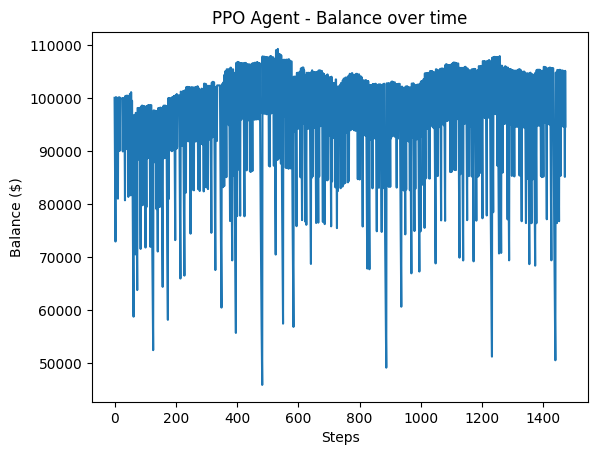

Action stats: {<Actions.Sell: 0>: 719, <Actions.Buy: 1>: 753}
Final Balance: $96548.71


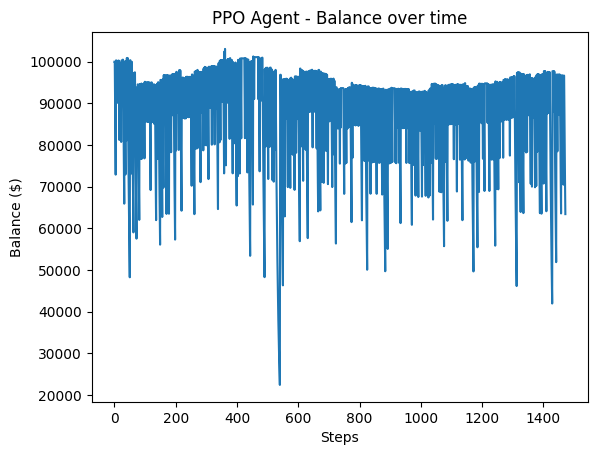

Action stats: {<Actions.Sell: 0>: 551, <Actions.Buy: 1>: 921}
Final Balance: $119750.32


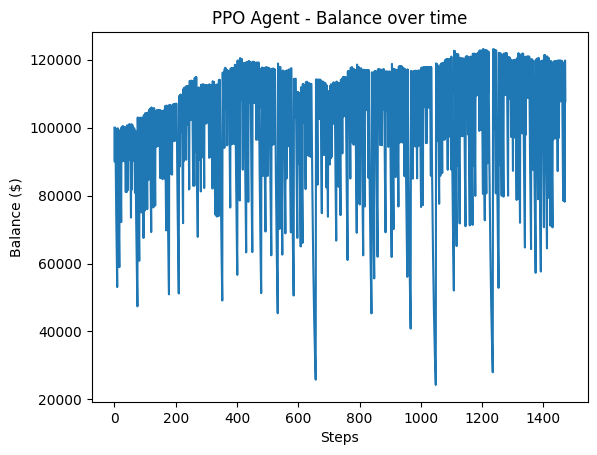

Action stats: {<Actions.Sell: 0>: 478, <Actions.Buy: 1>: 994}
Final Balance: $148045.90


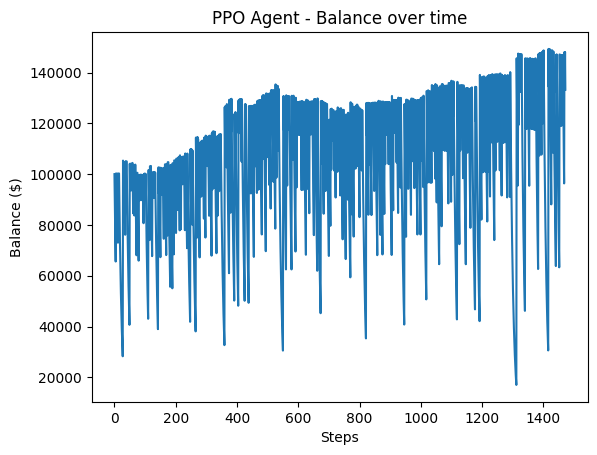

Action stats: {<Actions.Sell: 0>: 717, <Actions.Buy: 1>: 755}
Final Balance: $124080.24


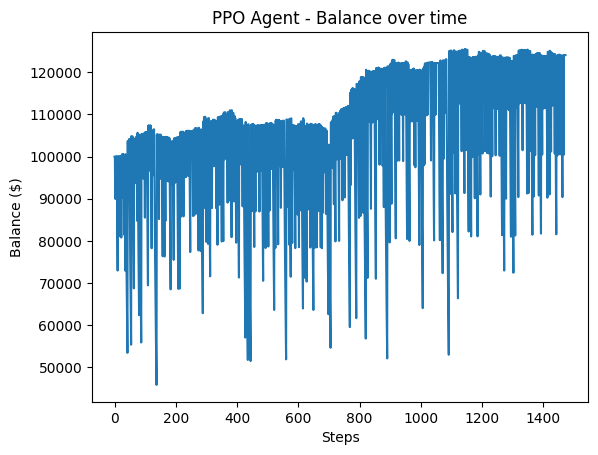

'\nQuestions/Answers\n- What do you think about the performance of this model?\nThe model has technically been profitable in that the cash balance is higher than what it started with. However, it is very hard to not be profitable given the extreme increase in the price of AAPL over the 15 years of data provided. You would have made significantly more by simply spending all of the initial balance on shares at the starting date, holding the shares, and selling at the ending date. You likely would have made significantly more over that time period by investing your initial balance in any number of asset classes.\n- Why do you think it has performed the way it has?\nEvery transaction that this model makes is the same size. That is why your balance history will have a lot of spikes and drops, as the model buys with 10% of its balance and then sells again instantly with 10% of its balance, making either a small profit or loss. An improvement that could be made here is calculating the positio

In [ ]:
# Load the data provided
data= pd.DataFrame()
data['Close'] = df.loc[:, ['close']].copy()
data['Date'] = df.loc[:, ['time']].copy()

# Set window size (lookback window), start and end index of data
window_size = 10
start_index = window_size
end_index = len(data)

# Create the environment using the pre-built 'stocks-v0', passing in the data loaded above
# window_size is how far the environment can look back at each step
# frame_bound is the bounding box of the environment, the size of our data
env = gym.make('stocks-v0', df=data, window_size=window_size, frame_bound=(start_index, end_index))
print("Observation Space:", env.observation_space)

for i in range(5):
    # Initialise cash balance tracking and other variables
    balance = 100000
    balance_history = [balance]
    shares_held = 0
    action_stats = {Actions.Sell: 0, Actions.Buy: 0}
    observation, info = env.reset(seed= 2024)

    # Train the PPO model
    model = PPO('MlpPolicy', env, verbose=0)
    model.learn(total_timesteps= 10000)
    step = 0
    while True:
        action, _states = model.predict(observation)
        current_price = env.unwrapped.prices[env.unwrapped._current_tick]

        observation, reward, terminated, truncated, info = env.step(action)

        trade_amount = balance * 0.10  # Trade with 10% of current balance

        if action == Actions.Buy.value:
            shares_to_buy = trade_amount / current_price
            shares_held += shares_to_buy
            balance -= trade_amount
            #print(f"{step}: BUY  {shares_to_buy:.2f} shares at ${current_price:.2f} | Balance: ${balance:.2f}")
        elif action == Actions.Sell.value and shares_held > 0:
            balance += shares_held * current_price
            #print(f"{step}: SELL {shares_held:.2f} shares at ${current_price:.2f} | Balance: ${balance:.2f}")
            shares_held = 0
        #else:
            #print(f"{step}: HOLD | Current price: ${current_price:.2f} | Balance: ${balance:.2f}")

        action_stats[Actions(action)] += 1
        balance_history.append(balance)

        step += 1
        if terminated or truncated:
            break

    # If we still hold shares at the end, sell them all
    if shares_held > 0:
        balance += shares_held * current_price
        #print(f"\nFinal SELL {shares_held:.2f} shares at ${current_price:.2f} | Balance: ${balance:.2f}")
        shares_held = 0

    env.close()

    print("Action stats:", action_stats)
    print(f"Final Balance: ${balance:.2f}")

    # Create a price chart showing buy/sell actions
    '''
    fig, ax = plt.subplots()
    env.unwrapped.render_all()
    ax.set_title("PPO Agent - Trading Actions")
    plt.show()
    '''

    # Create a chart showing cash balance over time
    fig2, ax2 = plt.subplots()
    ax2.plot(balance_history)
    ax2.set_title("PPO Agent - Balance over time")
    ax2.set_xlabel("Steps")
    ax2.set_ylabel("Balance ($)")

    plt.show()

"""
Questions/Answers
- What do you think about the performance of this model?
The model has technically been profitable in that the cash balance is higher than what it started with. However, it is very hard to not be profitable given the extreme increase in the price of AAPL over the 15 years of data provided. You would have made significantly more by simply spending all of the initial balance on shares at the starting date, holding the shares, and selling at the ending date. You likely would have made significantly more over that time period by investing your initial balance in any number of asset classes.
- Why do you think it has performed the way it has?
Every transaction that this model makes is the same size. That is why your balance history will have a lot of spikes and drops, as the model buys with 10% of its balance and then sells again instantly with 10% of its balance, making either a small profit or loss. An improvement that could be made here is calculating the position size based on the confidence the model has in its decision, taking a smaller position if less confident and a larger position if more confident. This model also does not account for any transaction costs or slippage which would be a key factor in a real trading scenario.
- How could the data we have selected impact the performance of the model?
This model uses 15 years of data which is a long time. It is very hard to not make money given a stock that has gone from around $4 to over $200! An interesting experiment would be to select some stock data for a company that has not seen the same extreme growth that Apple has seen and observe how the model performs.
"""
